# Module A — Accelerometer Characterization

**Test A.1** Static Noise Test — `imuLogflattest.csv`  
**Test A.2** Gravity Vector Check (Six-Face Calibration) — `imuLog6bottom.csv`

In [182]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

def load_imu(path):
    """Load IMU CSV, return dict of numpy arrays. Acceleration in milli-g."""
    with open(path, newline='') as f:
        f.readline()  # skip header
        rows = [line.strip().split(',') for line in f if line.strip()]
    t    = [datetime.strptime(r[0], '%Y/%m/%d %H:%M:%S.%f') for r in rows]
    dt   = np.array([(t[i] - t[0]).total_seconds() for i in range(len(t))])
    AccX = np.array([float(r[2]) for r in rows])
    AccY = np.array([float(r[3]) for r in rows])
    AccZ = np.array([float(r[4]) for r in rows])
    return {'t': t, 'dt': dt, 'AccX': AccX, 'AccY': AccY, 'AccZ': AccZ}

---
## Test A.1 — Static Noise Test

OLA placed flat and undisturbed. 



In [183]:
flat = load_imu('imuLogflattest.csv')

print(f"Flat-test samples : {len(flat['dt'])}")
print(f"Duration          : {flat['dt'][-1]:.1f} s")
fs = len(flat['dt']) / flat['dt'][-1]
print(f"Mean sample rate  : {fs:.2f} Hz")

Flat-test samples : 2839
Duration          : 257.6 s
Mean sample rate  : 11.02 Hz


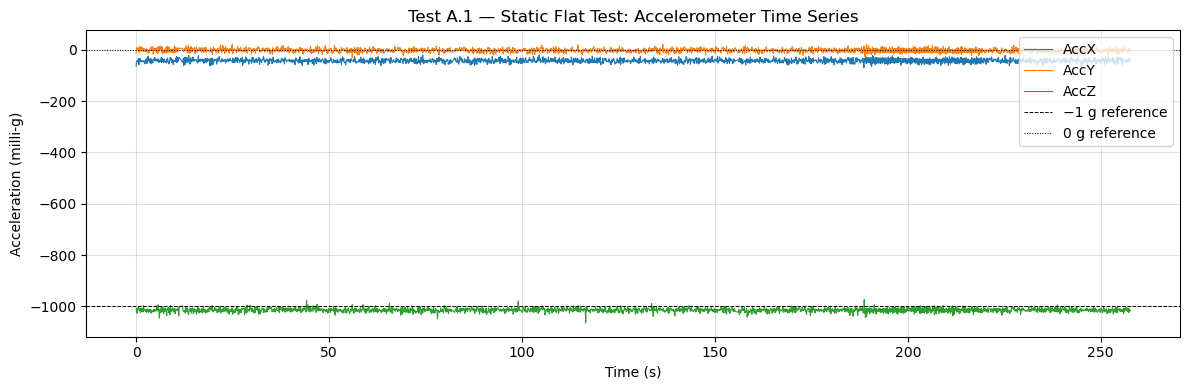

In [184]:
# ── Time-series plot of all three axes ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(flat['dt'], flat['AccX'], lw=0.8, label='AccX')
ax.plot(flat['dt'], flat['AccY'], lw=0.8, label='AccY')
ax.plot(flat['dt'], flat['AccZ'], lw=0.8, label='AccZ')

ax.axhline(-1000, color='k', ls='--', lw=0.7, label='−1 g reference')
ax.axhline(0,     color='k', ls=':',  lw=0.7, label='0 g reference')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (milli-g)')
ax.set_title('Test A.1 — Static Flat Test: Accelerometer Time Series')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Plot Z axis only for comparison and ease of viewing.

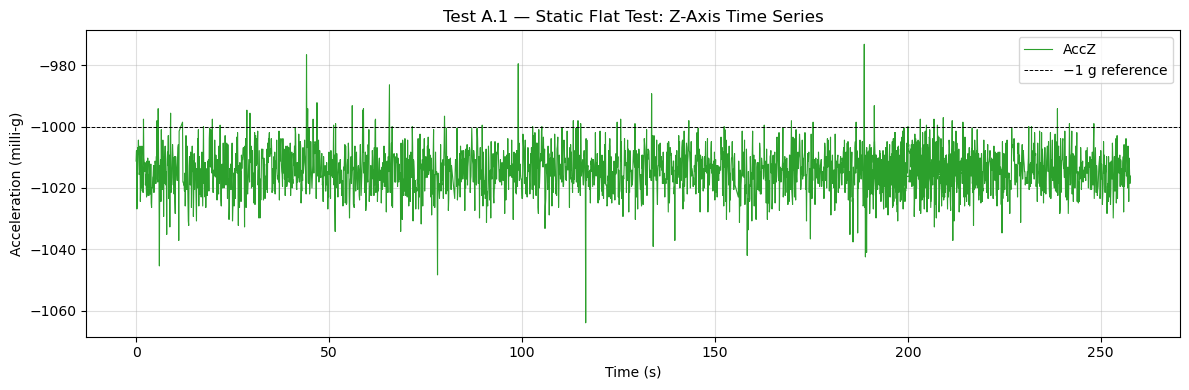

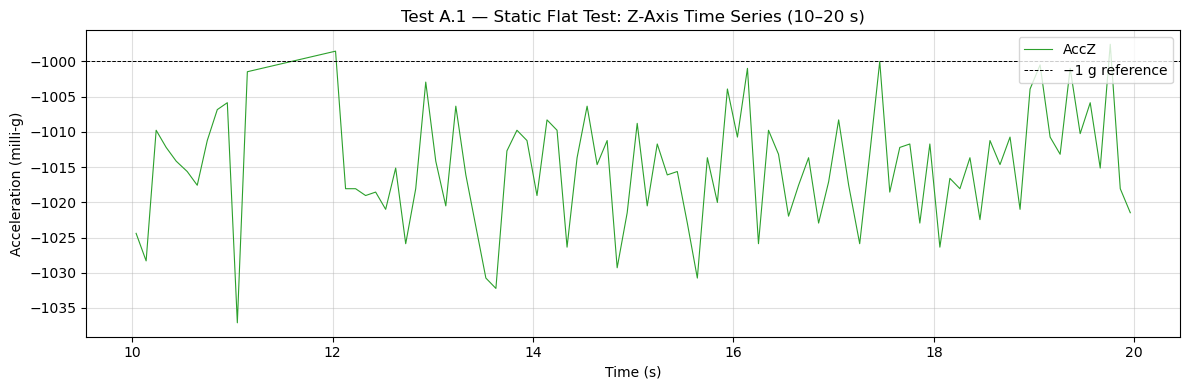

In [ ]:
# ── Z-axis only time-series plot for Test A.1 ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(flat['dt'], flat['AccZ'], lw=0.8, color='tab:green', label='AccZ')

ax.axhline(-1000, color='k', ls='--', lw=0.7, label='−1 g reference')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (milli-g)')
ax.set_title('Test A.1 — Static Flat Test: Z-Axis Time Series')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ── Z-axis zoom: 10–20 s window - to better show frequency and noise ─────────────────────────────────────────────
mask_zoom = (flat['dt'] >= 10) & (flat['dt'] <= 20)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(flat['dt'][mask_zoom], flat['AccZ'][mask_zoom], lw=0.8, color='tab:green', label='AccZ')

ax.axhline(-1000, color='k', ls='--', lw=0.7, label='−1 g reference')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (milli-g)')
ax.set_title('Test A.1 — Static Flat Test: Z-Axis Time Series (10–20 s)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

AccX: measured RMS = 6.8637 mg  |  expected = 0.5399 mg  |  ratio = 12.71
AccY: measured RMS = 6.7508 mg  |  expected = 0.5399 mg  |  ratio = 12.50
AccZ: measured RMS = 7.1196 mg  |  expected = 0.5399 mg  |  ratio = 13.19


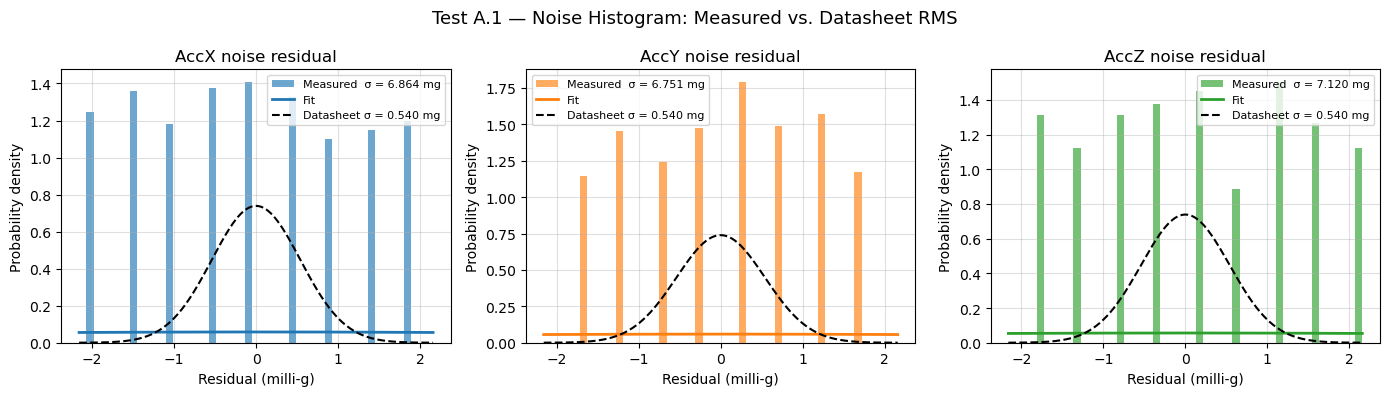

In [186]:
# ── Noise histogram with expected vs. measured RMS ───────────────────────────
# Remove the DC (mean) component so only the noise residual remains.
NOISE_DENSITY = 0.230   # mg/√Hz  (230 µg/√Hz converted to mg)
B             = fs / 2   # effective bandwidth (Hz)
sigma_expected = NOISE_DENSITY * np.sqrt(B)   # mg

axes_labels = ['X', 'Y', 'Z']
axes_data   = [flat['AccX'], flat['AccY'], flat['AccZ']]
colors      = ['tab:blue', 'tab:orange', 'tab:green']

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i, (lbl, data, col) in enumerate(zip(axes_labels, axes_data, colors)):
    residual = data - np.mean(data)
    sigma_meas = np.std(residual)

    bins  = np.linspace(-4 * sigma_expected, 4 * sigma_expected, 50)
    axs[i].hist(residual, bins=bins, color=col, alpha=0.65, density=True,
                label=f'Measured  σ = {sigma_meas:.3f} mg')

    x_gauss = np.linspace(bins[0], bins[-1], 300)
    gauss_meas    = (1/(sigma_meas    * np.sqrt(2*np.pi))) * np.exp(-0.5*(x_gauss/sigma_meas   )**2)
    gauss_expected= (1/(sigma_expected* np.sqrt(2*np.pi))) * np.exp(-0.5*(x_gauss/sigma_expected)**2)

    axs[i].plot(x_gauss, gauss_meas,     col,  lw=2, label='Fit')
    axs[i].plot(x_gauss, gauss_expected, 'k--', lw=1.5,
                label=f'Datasheet σ = {sigma_expected:.3f} mg')

    axs[i].set_title(f'Acc{lbl} noise residual')
    axs[i].set_xlabel('Residual (milli-g)')
    axs[i].set_ylabel('Probability density')
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.4)
    print(f'Acc{lbl}: measured RMS = {sigma_meas:.4f} mg  |  '
          f'expected = {sigma_expected:.4f} mg  |  '
          f'ratio = {sigma_meas/sigma_expected:.2f}')

fig.suptitle('Test A.1 — Noise Histogram: Measured vs. Datasheet RMS', fontsize=13)
plt.tight_layout()
plt.show()


# Static Accelerometer Test — Z-Up Orientation Analysis

---

## 1. Expected Values per Axis & Datasheet Zero-g Output

With the sensor in **Z-up** orientation, gravity ($g \approx 9.81\, \text{m/s}^2$) projects
entirely onto the Z-axis. The expected ideal readings are:

| Axis | Expected Output | Reason |
|------|----------------|--------|
| X    | 0.000 g        | Perpendicular to gravity |
| Y    | 0.000 g        | Perpendicular to gravity |
| Z    | +1.000 g       | Aligned with gravity, positive up convention |

**At rest the Z-axis reads ≈ −1 g (specific force = table normal force)  
while X and Y read ≈ 0 g. The data sheet refers to the steady state z-axis as positive (1)g, This means we had the sensor orriented upside down and the positive zaxis pointed down with gravity.

- The zero-g offset is the output when **no acceleration** is applied to that axis
- zero-g offset tolerance: $\pm 50\, \text{mg}$
  -> This means even a "perfect" sensor at rest on X/Y may read $ 1 \pm 0.050\,g $
  before calibration ( which ours does.)

> **Key distinction:** The zero-g output is the *bias* $b$ in your calibration model.
> In part 2: The corrected reading subtracts this: $a_{corrected} = (a_{raw} - b)/s$

---

## 2. Quantifying Noise — The Right Statistic and Why

**Use the standard deviation ($\sigma$), not the peak-to-peak range.**

$$\sigma = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N}(a_i - \bar{a})^2}$$

| Statistic | Use for | Problem if used for noise |
|-----------|---------|--------------------------|
| Mean $\bar{a}$ | Estimating bias | Tells you *offset*, not spread |
| Std Dev $\sigma$ | **Noise quantification** ✓ | None — this is the right choice |
| Peak-to-peak | Worst-case bounds | Sensitive to outliers, grows with $N$ |
| RMS | Total signal power | Equals $\sigma$ only when mean $\approx 0$ |

**Why $\sigma$?**
- MEMS accelerometer noise is well-modeled as **white Gaussian noise** in the measurement band
- $\sigma$ is the natural parameter of a Gaussian distribution
- It is stable and converges as $N$ increases, unlike peak-to-peak
- It directly maps to the datasheet **noise spectral density** specification

---

## 3. Datasheet Noise Prediction vs. Your Measurement

**From the noise spectral density (NSD) in Table 2:**

The datasheet gives noise density in units of $\mu g / \sqrt{\text{Hz}}$.
The predicted RMS noise over a bandwidth $f_{BW}$ is:

$$\sigma_{predicted} = NSD \times \sqrt{f_{BW}}$$

For a digital sensor sampled at $f_s$, the effective noise bandwidth is:

$$f_{BW} = \frac{f_s}{2} \quad \text{(Nyquist, for a flat response)}$$

So the full prediction is:

$$\boxed{\sigma_{predicted} = NSD \times \sqrt{\frac{f_s}{2}}}$$



| Parameter | Symbol | Example Value |
|-----------|--------|--------------|
| Noise spectral density | $NSD$ | $230\, \mu g/\sqrt{\text{Hz}}$ |
| Sample rate | $f_s$ | $10\, \text{Hz}$ |
| Bandwidth | $f_{BW}$ | $5\, \text{Hz}$ |
| Predicted RMS noise | $\sigma_{predicted}$ | $230 \times \sqrt{5} \approx 514\, \mu g$ |

**Comparing to your measurement:**

$$\text{Ratio} = \frac{\sigma_{measured}}{\sigma_{predicted}}$$

- Ratio $\approx 1.0$: sensor behaves as datasheet predicts ✓
- Ratio $> 1.5$: excess noise — check for vibration, EMI, power supply noise, or
  insufficient averaging
- Ratio $< 0.7$: your filter or ODR setting may be reducing bandwidth below $f_s/2$


** Our Data found: $$12 \approx \frac{\sigma_{measured}}{\sigma_{predicted}}$$ 
 Noise values of approximately $6-7 mg$ were found. This means that for some reason our sensors was exposed to background vibrations well above what can be considered noise.

---

## 4. OLA Axis Orientation When Flat & Sign/Magnitude Implications

**OLA = Output Limiting Axis** (the axis aligned with gravity in a given orientation).

When the sensor is **lying flat** (Z-up):

$$\text{OLA} = \textbf{Z-axis}$$

This is because:
- The Z-axis is **perpendicular to the PCB plane** in a standard MEMS footprint
- Gravity ($-g$ in the inertial frame, or $+g$ in the sensor frame for Z-up) projects
  entirely onto Z
- X and Y are in the horizontal plane — orthogonal to $\vec{g}$

**Sign and magnitude implications:**

$$a_Z^{raw} = s_Z \cdot (+1\,g) + b_Z$$

| Effect | Impact on reading |
|--------|------------------|
| Positive $b_Z$ | Shifts Z reading above +1 g |
| Negative $b_Z$ | Shifts Z reading below +1 g |
| $s_Z > 1$ | Z reading magnitude inflated |
| $s_Z < 1$ | Z reading magnitude suppressed |
| Cross-axis coupling | X, Y show small non-zero values even though gravity is purely on Z |

**Physical interpretation:**
- If Z reads **+1 g**: sensor defines Z-up as positive (right-hand convention, common)
- If Z reads **−1 g** when physically Z-up: sensor uses **Z-down positive** convention —
  check your datasheet orientation diagram
- X and Y deviations from 0 g when flat directly reveal your **cross-axis coupling**
  and **zero-g bias** on those axes without needing to flip the sensor


---
## Test A.2 — Gravity Vector Check (Six-Face Calibration)

The OLA is rotated through all six face-down orientations. For each axis the calibration model is:

$$a_\text{corrected} = \frac{a_\text{raw} - b}{s}$$

With two opposing orientations on axis $i$ (raw mean when +1 g expected = $p_i$; when −1 g expected = $n_i$):

$$b_i = \frac{p_i + n_i}{2}, \qquad s_i = \frac{p_i - n_i}{2}$$

**Variable definitions:**

| Symbol | Description | Units |
|--------|-------------|-------|
| $a_\text{corrected}$ | Calibration-corrected acceleration output | milli-g |
| $a_\text{raw}$ | Raw (uncorrected) accelerometer reading | milli-g |
| $b_i$ | Bias offset for axis $i$ — midpoint error between the two opposing readings | milli-g |
| $s_i$ | Scale factor for axis $i$ — half the span between the two opposing readings (ideal = 1000 mg/g) | milli-g/g |
| $p_i$ | Mean raw reading on axis $i$ when +1 g is expected (positive face down) | milli-g |
| $n_i$ | Mean raw reading on axis $i$ when −1 g is expected (negative face down) | milli-g |
| $i$ | Axis index: X, Y, or Z | — |

Faces are detected automatically using a threshold on the dominant axis.

In [187]:
six = load_imu('imuLog6bottom.csv')

print(f"Six-face samples  : {len(six['dt'])}")
print(f"Duration          : {six['dt'][-1]:.1f} s")

Six-face samples  : 833
Duration          : 84.2 s


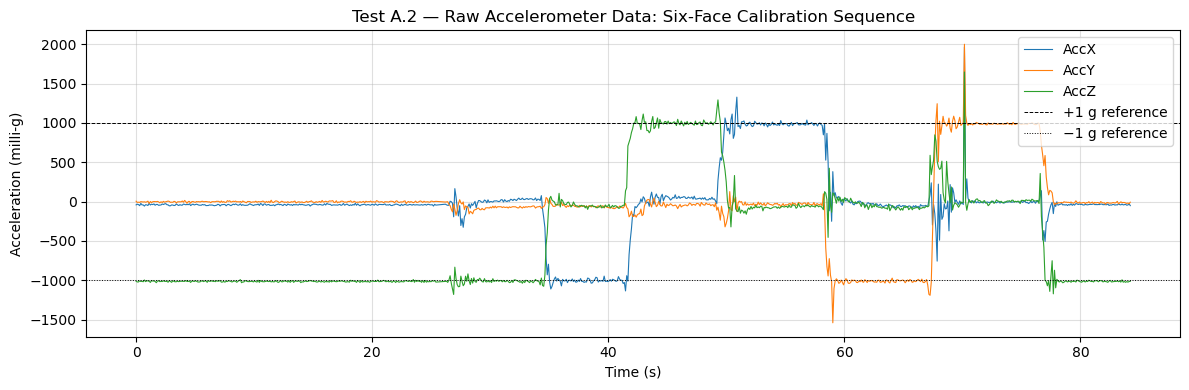

In [188]:
# ── Raw time-series plot of six-face data ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(six['dt'], six['AccX'], lw=0.8, label='AccX')
ax.plot(six['dt'], six['AccY'], lw=0.8, label='AccY')
ax.plot(six['dt'], six['AccZ'], lw=0.8, label='AccZ')

ax.axhline( 1000, color='k', ls='--', lw=0.7, label='+1 g reference')
ax.axhline(-1000, color='k', ls=':',  lw=0.7, label='−1 g reference')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (milli-g)')
ax.set_title('Test A.2 — Raw Accelerometer Data: Six-Face Calibration Sequence')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [189]:
# ── Detect face orientations ─────────────────────────────────────────────────
THRESHOLD = 800  # milli-g  — axis reading above this magnitude → dominant axis

AX = six['AccX']
AY = six['AccY']
AZ = six['AccZ']

# Assign a label to every sample
face_label = np.full(len(AX), '', dtype=object)
face_label[( AZ >  THRESHOLD)] = '+Z'
face_label[( AZ < -THRESHOLD)] = '-Z'
face_label[( AX >  THRESHOLD)] = '+X'
face_label[( AX < -THRESHOLD)] = '-X'
face_label[( AY >  THRESHOLD)] = '+Y'
face_label[( AY < -THRESHOLD)] = '-Y'

for face in ['+X', '-X', '+Y', '-Y', '+Z', '-Z']:
    n = np.sum(face_label == face)
    print(f"{face}: {n} samples ({n/len(AX)*100:.1f} %)")

unclassified = np.sum(face_label == '')
print(f"Unclassified (transition): {unclassified} samples")

+X: 86 samples (10.3 %)
-X: 68 samples (8.2 %)
+Y: 88 samples (10.6 %)
-Y: 88 samples (10.6 %)
+Z: 78 samples (9.4 %)
-Z: 411 samples (49.3 %)
Unclassified (transition): 14 samples


In [190]:
# ── Compute bias and scale factor per axis ───────────────────────────────────
def face_mean(axis_data, face_label, face):
    mask = face_label == face
    if mask.sum() == 0:
        raise ValueError(f"No samples found for face '{face}' — adjust THRESHOLD or check data")
    return np.mean(axis_data[mask])

results = {}
for axis, data in [('X', AX), ('Y', AY), ('Z', AZ)]:
    pos = face_mean(data, face_label, f'+{axis}')
    neg = face_mean(data, face_label, f'-{axis}')
    b = (pos + neg) / 2          # bias  (milli-g)
    s = (pos - neg) / 2          # scale (milli-g per g, ideal = 1000)
    results[axis] = {'pos': pos, 'neg': neg, 'bias': b, 'scale': s}
    print(f"Axis {axis}: +face={pos:+.2f} mg  -face={neg:+.2f} mg  "
          f"bias={b:+.2f} mg  scale={s:.2f} mg/g")

# Extract calibration parameters
bx, sx  = results['X']['bias'], results['X']['scale']
by_, sy = results['Y']['bias'], results['Y']['scale']
bz, sz  = results['Z']['bias'], results['Z']['scale']

# ── Per-face norm analysis ────────────────────────────────────────────────────
G = 1000.0  # 1 g in milli-g

print()
print("─" * 66)
print(f"{'Face':<6} {'‖a_raw‖ (mg)':>14} {'‖a_corr‖ (mg)':>15} {'|‖a_corr‖ − 1g| (mg)':>22}")
print("─" * 66)

for face in ['+X', '-X', '+Y', '-Y', '+Z', '-Z']:
    mask = face_label == face

    # Mean raw vector for this face
    mx = np.mean(AX[mask])
    my = np.mean(AY[mask])
    mz = np.mean(AZ[mask])
    norm_raw = np.sqrt(mx**2 + my**2 + mz**2)

    # Apply bias and scale correction (output in milli-g)
    mx_c = (mx - bx) / sx * 1000
    my_c = (my - by_) / sy * 1000
    mz_c = (mz - bz) / sz * 1000
    norm_corr = np.sqrt(mx_c**2 + my_c**2 + mz_c**2)

    residual = abs(norm_corr - G)

    print(f"{face:<6} {norm_raw:>14.2f} {norm_corr:>15.2f} {residual:>22.2f}")

print("─" * 66)

Axis X: +face=+983.60 mg  -face=-1007.02 mg  bias=-11.71 mg  scale=995.31 mg/g
Axis Y: +face=+1003.50 mg  -face=-1019.95 mg  bias=-8.23 mg  scale=1011.72 mg/g
Axis Z: +face=+995.65 mg  -face=-1014.72 mg  bias=-9.54 mg  scale=1005.19 mg/g

──────────────────────────────────────────────────────────────────
Face     ‖a_raw‖ (mg)   ‖a_corr‖ (mg)   |‖a_corr‖ − 1g| (mg)
──────────────────────────────────────────────────────────────────
+X             985.87         1001.45                   1.45
-X            1009.20         1001.45                   1.45
+Y            1005.38         1002.54                   2.54
-Y            1020.74         1000.45                   0.45
+Z             997.39         1001.72                   1.72
-Z            1015.59         1000.41                   0.41
──────────────────────────────────────────────────────────────────


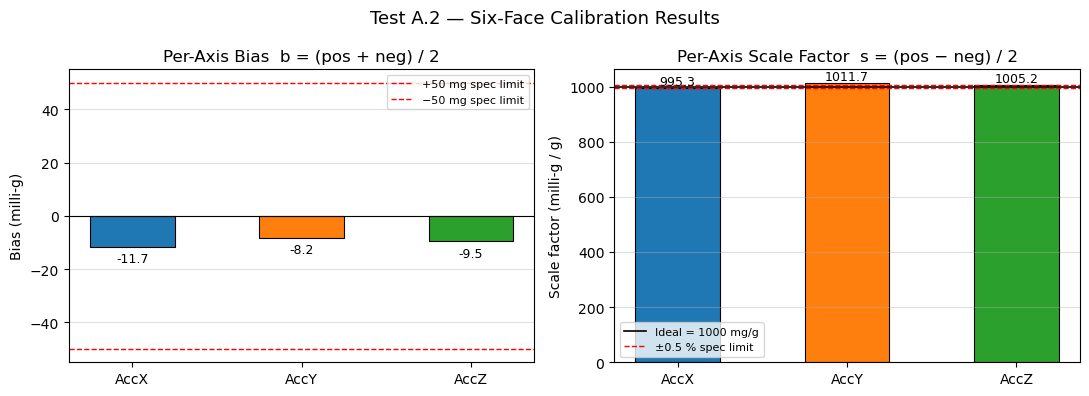

In [191]:
# ── Six-face bar chart: per-axis bias and scale factor ───────────────────────
axes_labels = ['X', 'Y', 'Z']
biases      = [results[a]['bias']  for a in axes_labels]
scales      = [results[a]['scale'] for a in axes_labels]

x = np.arange(3)
width = 0.5

fig, (ax_b, ax_s) = plt.subplots(1, 2, figsize=(11, 4))

# Bias
bars_b = ax_b.bar(x, biases, width, color=['tab:blue','tab:orange','tab:green'],
                  edgecolor='k', linewidth=0.8)
ax_b.axhline(0, color='k', lw=0.8)
ax_b.axhline( 50, color='r', ls='--', lw=1.0, label='+50 mg spec limit')
ax_b.axhline(-50, color='r', ls='--', lw=1.0, label='−50 mg spec limit')
ax_b.set_xticks(x); ax_b.set_xticklabels([f'Acc{a}' for a in axes_labels])
ax_b.set_ylabel('Bias (milli-g)')
ax_b.set_title('Per-Axis Bias  b = (pos + neg) / 2')
ax_b.legend(fontsize=8)
ax_b.grid(True, axis='y', alpha=0.4)
for bar, val in zip(bars_b, biases):
    ax_b.text(bar.get_x() + bar.get_width()/2, val + np.sign(val)*2,
              f'{val:+.1f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

# Scale factor
bars_s = ax_s.bar(x, scales, width, color=['tab:blue','tab:orange','tab:green'],
                  edgecolor='k', linewidth=0.8)
ax_s.axhline(1000, color='k', ls='-',  lw=1.2, label='Ideal = 1000 mg/g')
ax_s.axhline(1005, color='r', ls='--', lw=1.0, label='±0.5 % spec limit')
ax_s.axhline( 995, color='r', ls='--', lw=1.0)
ax_s.set_xticks(x); ax_s.set_xticklabels([f'Acc{a}' for a in axes_labels])
ax_s.set_ylabel('Scale factor (milli-g / g)')
ax_s.set_title('Per-Axis Scale Factor  s = (pos − neg) / 2')
ax_s.legend(fontsize=8)
ax_s.grid(True, axis='y', alpha=0.4)
for bar, val in zip(bars_s, scales):
    ax_s.text(bar.get_x() + bar.get_width()/2, val + 1,
              f'{val:.1f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Test A.2 — Six-Face Calibration Results', fontsize=13)
plt.tight_layout()
plt.show()

Raw magnitude :  mean = 1014.18 mg   std = 98.40 mg
Cal magnitude :  mean = 1005.55 mg   std = 98.13 mg
Target = 1000.00 mg


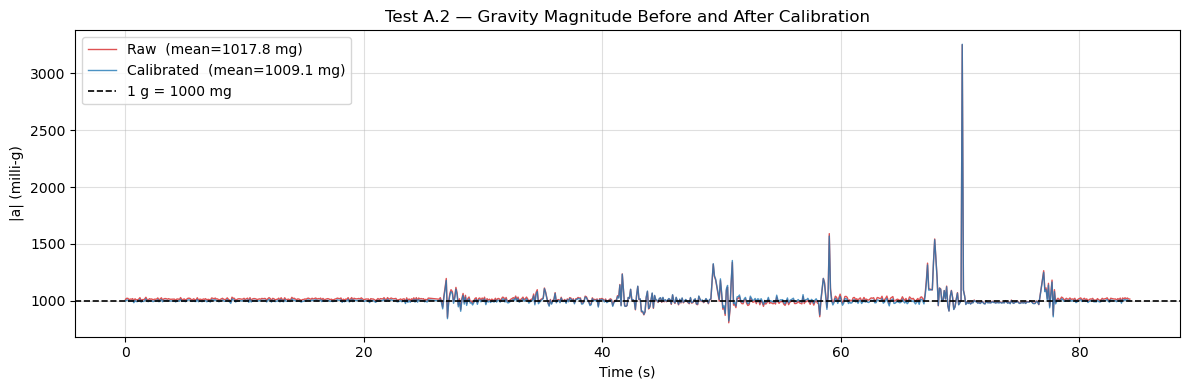

In [192]:
# ── Gravity magnitude before and after calibration correction ────────────────
bx, sx = results['X']['bias'], results['X']['scale']
by_, sy = results['Y']['bias'], results['Y']['scale']
bz, sz = results['Z']['bias'], results['Z']['scale']

# Raw magnitude
mag_raw = np.sqrt(AX**2 + AY**2 + AZ**2)

# Corrected axes (output in milli-g, 1 g = 1000 mg)
AX_c = (AX - bx) / sx * 1000
AY_c = (AY - by_) / sy * 1000
AZ_c = (AZ - bz) / sz * 1000
mag_cal = np.sqrt(AX_c**2 + AY_c**2 + AZ_c**2)

print(f"Raw magnitude :  mean = {np.mean(mag_raw):.2f} mg   std = {np.std(mag_raw):.2f} mg")
print(f"Cal magnitude :  mean = {np.mean(mag_cal):.2f} mg   std = {np.std(mag_cal):.2f} mg")
print(f"Target = 1000.00 mg")

fig, ax = plt.subplots(figsize=(12, 4))

# Use only classified samples for clarity
classified = face_label != ''
ax.plot(six['dt'][classified], mag_raw[classified],
        color='tab:red',  lw=1.0, alpha=0.8, label=f'Raw  (mean={np.mean(mag_raw[classified]):.1f} mg)')
ax.plot(six['dt'][classified], mag_cal[classified],
        color='tab:blue', lw=1.0, alpha=0.8, label=f'Calibrated  (mean={np.mean(mag_cal[classified]):.1f} mg)')

ax.axhline(1000, color='k', ls='--', lw=1.2, label='1 g = 1000 mg')

ax.set_xlabel('Time (s)')
ax.set_ylabel('|a| (milli-g)')
ax.set_title('Test A.2 — Gravity Magnitude Before and After Calibration')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

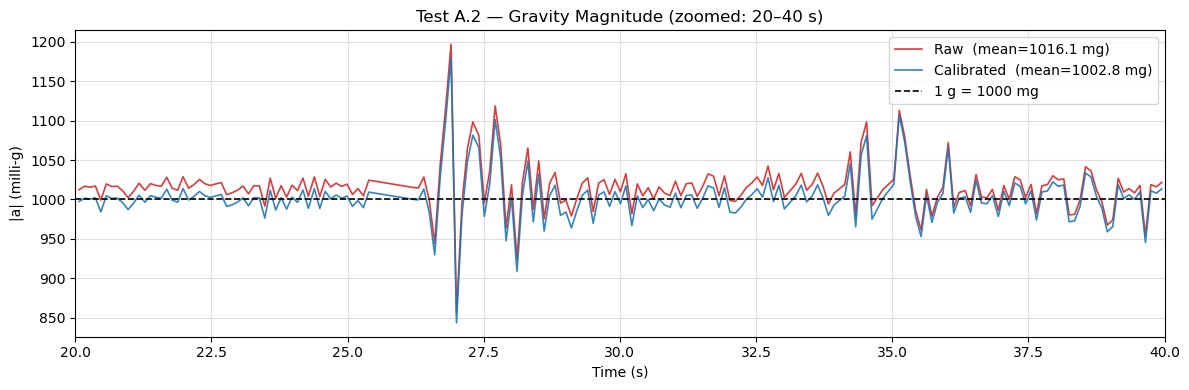

In [193]:
# ── Zoomed view: 20–40 s window ──────────────────────────────────────────────
t_zoom = six['dt'][classified]
mask_zoom = (t_zoom >= 20) & (t_zoom <= 40)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(t_zoom[mask_zoom], mag_raw[classified][mask_zoom],
        color='tab:red',  lw=1.2, alpha=0.9,
        label=f'Raw  (mean={np.mean(mag_raw[classified][mask_zoom]):.1f} mg)')
ax.plot(t_zoom[mask_zoom], mag_cal[classified][mask_zoom],
        color='tab:blue', lw=1.2, alpha=0.9,
        label=f'Calibrated  (mean={np.mean(mag_cal[classified][mask_zoom]):.1f} mg)')

ax.axhline(1000, color='k', ls='--', lw=1.2, label='1 g = 1000 mg')

ax.set_xlim(20, 40)
ax.set_xlabel('Time (s)')
ax.set_ylabel('|a| (milli-g)')
ax.set_title('Test A.2 — Gravity Magnitude (zoomed: 20–40 s)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Accelerometer 6-Position Calibration Analysis

---

## 1. Solving for Bias *b* and Scale Factor *s* from Two Opposing Orientations

When you place the sensor with **+Z up**, gravity projects fully onto the Z-axis:

$$a_{raw}^+ \approx +\frac{g}{s} + b$$

When you flip to **−Z up**:

$$a_{raw}^- \approx -\frac{g}{s} + b$$

These are two equations in two unknowns. Solving them:

**Bias** (average of the two raw readings — gravity cancels out):

$$b = \frac{a_{raw}^+ + a_{raw}^-}{2}$$

**Scale factor** (half the difference, normalized by *g*):

$$s = \frac{a_{raw}^+ - a_{raw}^-}{2g}$$

Then your corrected reading is:

$$a_{corrected} = \frac{a_{raw} - b}{s}$$

This works because the two orientations create a symmetric bracket around the true ±g values —
bias shifts both readings equally, while scale factor stretches them symmetrically.

---

## 2. What Should ‖a‖ Equal, and Does Your Data Satisfy It?

In every static orientation, only gravity acts on the sensor, so the **true total acceleration
magnitude must equal 1 g** regardless of orientation:

$$\|a\| = \sqrt{a_x^2 + a_y^2 + a_z^2} = 1\,g \approx 9.81\,\text{m/s}^2$$

YES, our data does satisfy this metric each corrected values is with in $.5\%$. 
---

## 3. Cross-Axis Coupling in 6-Face Data

Cross-axis coupling means that when gravity is along Z, you also see a small spurious signal
on X and Y — due to sensor misalignment or crosstalk in the MEMS element.

**What it looks like in the data:**

When Z-axis is fully stimulated (+Z up), ideally:

| Axis | Expected | Actual (example) |
|------|----------|------------------|
| X    | 0.000 g  | +0.012 g         |
| Y    | 0.000 g  | −0.008 g         |
| Z    | +1.000 g | +0.998 g         |

Those non-zero X and Y readings *are* the cross-axis coupling.

**Estimating coupling coefficients:**

The full model is a 3×3 matrix equation:

$$\vec{a}_{corrected} = S^{-1}(\vec{a}_{raw} - \vec{b})$$

where $S$ is the sensitivity matrix:

$$S = \begin{bmatrix} s_{xx} & s_{xy} & s_{xz} \\\\ s_{yx} & s_{yy} & s_{yz} \\\\ s_{zx} & s_{zy} & s_{zz} \end{bmatrix}$$

The **diagonal terms** ($s_{xx}, s_{yy}, s_{zz}$) are your per-axis scale factors.
The **off-diagonal terms** are the cross-axis coupling coefficients. From 6-face results
you can estimate them directly:

$$s_{xz} \approx \left. a_x^{raw} \right|_{+Z\\,face}$$

(i.e., the X reading when Z should be 1 g and Y = 0)


---
##  Cross-Axis Coupling Estimation (Flat Test)

Using `imuLogflattest.csv` (sensor lying flat, Z-axis fully stimulated ≈ −1 g).


In [194]:
# ── Cross-axis coupling from flat test (Z-axis stimulated) ───────────────────
# 'flat' is already loaded from imuLogflattest.csv above.
# The sensor lies flat, so AccZ ≈ −1000 mg (Z-down positive convention).

mean_x = np.mean(flat['AccX'])   # should be ≈ 0 mg; any residual = coupling
mean_y = np.mean(flat['AccY'])   # should be ≈ 0 mg; any residual = coupling
mean_z = np.mean(flat['AccZ'])   # ≈ −1000 mg (OLA)

# Coupling coefficients: ratio of non-OLA mean to OLA mean (× 100 for %)
# Sign convention: divide by mean_z (negative here), so a negative X mean
# and a negative Z mean give a positive coupling fraction.
C_xz = (mean_x / mean_z) * 100   # % of Z input appearing on X output
C_yz = (mean_y / mean_z) * 100   # % of Z input appearing on Y output

# Std dev on non-OLA axes gives per-axis noise floor context
std_x = np.std(flat['AccX'] - mean_x)
std_y = np.std(flat['AccY'] - mean_y)
std_z = np.std(flat['AccZ'] - mean_z)

print("=" * 58)
print("  Cross-Axis Coupling Estimation — imuLogflattest.csv")
print("=" * 58)
print(f"\n  OLA axis : Z   (mean = {mean_z:+.2f} mg)")
print(f"\n  Mean readings on non-stimulated axes:")
print(f"    AccX mean : {mean_x:+.3f} mg   (noise σ = {std_x:.3f} mg)")
print(f"    AccY mean : {mean_y:+.3f} mg   (noise σ = {std_y:.3f} mg)")
print()
print(f"  Cross-axis coupling coefficients:")
print(f"    C_xz = AccX_mean / |AccZ_mean| = {C_xz:+.4f} %")
print(f"    C_yz = AccY_mean / |AccZ_mean| = {C_yz:+.4f} %")
print()

# Significance check: is the coupling larger than the noise floor?
sig_x = abs(mean_x) / std_x if std_x > 0 else float('inf')
sig_y = abs(mean_y) / std_y if std_y > 0 else float('inf')
print(f"  Signal-to-noise on coupling:")
print(f"    X: |mean| / σ = {sig_x:.1f}x  →  {'statistically significant' if sig_x > 3 else 'within noise floor'}")
print(f"    Y: |mean| / σ = {sig_y:.1f}x  →  {'statistically significant' if sig_y > 3 else 'within noise floor'}")
print("=" * 58)
print("\nNote: Only C_xz and C_yz are extractable from this single-orientation")



  Cross-Axis Coupling Estimation — imuLogflattest.csv

  OLA axis : Z   (mean = -1014.31 mg)

  Mean readings on non-stimulated axes:
    AccX mean : -42.909 mg   (noise σ = 6.864 mg)
    AccY mean : -2.192 mg   (noise σ = 6.751 mg)

  Cross-axis coupling coefficients:
    C_xz = AccX_mean / |AccZ_mean| = +4.2304 %
    C_yz = AccY_mean / |AccZ_mean| = +0.2161 %

  Signal-to-noise on coupling:
    X: |mean| / σ = 6.3x  →  statistically significant
    Y: |mean| / σ = 0.3x  →  within noise floor

Note: Only C_xz and C_yz are extractable from this single-orientation
